# Manual surrogate: generate data → explore → train

This notebook walks the same pipeline the agent tries to automate, using the
library APIs directly so you can see the data, understand the task, and beat
the agent by hand.

**Task.** Learn a map from tokamak shaping parameters to the poloidal-flux field:

$$(R_0,\, a,\, \kappa,\, \delta,\, I_p) \;\mapsto\; \psi(R,Z) \in \mathbb{R}^{n_Z \times n_R}$$

Ground truth comes from TokaMaker (Grad–Shafranov FEM). Outside the LCFS, $\psi$
is stored as NaN.

**Libraries used**
- `autotokamak.data` — sample parameters + solve + write HDF5
- `autotokamak.surrogate` — load, split, PCA, RMSE metrics, model zoo
- `autotokamak.surrogate` — sklearn model zoo (`poly_ridge`, `kernel_ridge`, `mlp`, `gp`)

**OFT note.** `OpenFUSIONToolkit.OFT_env` is a process-wide singleton. Generate
data once per kernel; do not multithread solves.

## 0. Setup

**Kernel:** select **Python (autotokamak)** (the project `venv`). If you only see a generic Python 3 kernel, that is why `import autotokamak` fails.

One-time install from the repo root:

```bash
source venv/bin/activate
pip install -e ".[ml,dev]"
python -m ipykernel install --user --name=autotokamak --display-name="Python (autotokamak)"
```

Then in Cursor/VS Code: kernel picker → **Python (autotokamak)** → re-run from the top.

In [46]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Resolve repo root whether cwd is repo root or notebooks/.
HERE = Path.cwd().resolve()
REPO_ROOT = HERE if (HERE / "pyproject.toml").is_file() else HERE.parent
SRC = REPO_ROOT / "src"
if SRC.is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RUN_DIR = REPO_ROOT / "notebooks" / "manual_surrogate_run"
RUN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Python     → {sys.executable}")
print(f"Repo root  → {REPO_ROOT}")
print(f"Artifacts  → {RUN_DIR}")

try:
    import autotokamak
    print(f"autotokamak → {autotokamak.__file__}")
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "autotokamak is not importable in this kernel.\n"
        "Select kernel 'Python (autotokamak)' (project venv), or run:\n"
        f'  "{REPO_ROOT / "venv" / "bin" / "python"}" -m pip install -e ".[ml,dev]"\n'
        "from the repo root, then re-select that interpreter as the notebook kernel."
    ) from exc

Python     → /Users/hindy/Desktop/Deep Deka/autokamak/venv/bin/python
Repo root  → /Users/hindy/Desktop/Deep Deka/autokamak
Artifacts  → /Users/hindy/Desktop/Deep Deka/autokamak/notebooks/manual_surrogate_run
autotokamak → /Users/hindy/Desktop/Deep Deka/autokamak/src/autotokamak/__init__.py


## 1. What are we learning?

Five tokamak shaping / current knobs go in; a full poloidal-flux map comes out:

$$(R_0,\, a,\, \kappa,\, \delta,\, I_p) \;\mapsto\; \psi(R,Z)$$

### Dimensions (this notebook’s defaults)

| Array | Shape | Meaning |
|---|---|---|
| **X** | `(N, 5)` | columns = `(r0, a, kappa, delta, Ip)` |
| **Y (raw)** | `(N, 96, 64)` | $\psi$ on the `(Z, R)` grid = **6144** numbers per sample |
| **Y (after PCA)** | `(N, n_pca)` | typically `n_pca ≈ 8–20` coefficients |

`N` is the number of **successful** solves (≤ `N_SAMPLES`; failures are dropped).  
With the default grid, each target is a **96 × 64** field (`nz × nr`), not a single scalar.

### Why PCA?

Regressing 6144 outputs from only tens–hundreds of samples is high-dimensional and noisy. Equilibrium $\psi$ fields are smooth and structurally similar across the shaping box: most of the map is shared “mean equilibrium” structure, and sample-to-sample differences live in a **small number of spatial modes**.

PCA finds those modes on the **training** $\psi$ maps:

1. Fit PCA on train $\psi$ → keep the top `n_pca` components  
2. Train a regressor: **X `(N, 5)` → PCA coeffs `(N, n_pca)`**  
3. At predict time: coeffs → `inverse_transform` → full $\psi` `(M, 96, 64)`

That is a good idea here because:

- **Compression:** 6144 → ~12 numbers while keeping ~95–99% of variance (check the cumulative-variance plot below)  
- **Better learning:** the model only has to predict a few coefficients instead of every pixel  
- **Physics-aligned:** GS equilibria are smooth / low-rank on this grid, so PCA is not discarding the signal that matters for a surrogate  

RMSE is always scored in the **original $\psi$ space** (after inverse-transform), never in coefficient space.

In [ ]:
PARAM_ORDER = ("r0", "a", "kappa", "delta", "Ip")
PARAM_LABELS = {
    "r0": r"$R_0$ [m]",
    "a": r"$a$ [m]",
    "kappa": r"$\kappa$",
    "delta": r"$\delta$",
    "Ip": r"$I_p$ [A]",
}

# Tiny-but-useful smoke config. Bump n_samples to 200–500 for a serious model.
# Use the shipped shaping box so isoflux success stays high.
N_SAMPLES = 10000          # ~few minutes on a laptop; raise when ready
GRID_NR, GRID_NZ = 64, 96  # pretty maps; use 32×48 for faster PCA experiments
FORCE_REGENERATE = True

cfg_dict = {
    "sampling": {"method": "lhs", "n_samples": N_SAMPLES, "seed": 0},
    "parameters": {
        "r0":    {"low": 0.35, "high": 0.55},
        "a":     {"low": 0.10, "high": 0.20},
        "kappa": {"low": 1.0,  "high": 1.6},
        "delta": {"low": 0.0,  "high": 0.4},
        "Ip":    {"low": 8.0e4, "high": 2.0e5},
    },
    "fixed": {
        "z0": 0.0,
        "F0": 0.10752,
        "npts": 80,
        "mesh_dx": 0.015,
        "solver_order": 1,
        "Ip_ratio": 1.0,
        "init_psi_method": "isoflux",
    },
    "output_grid": {
        "R": {"min": 0.15, "max": 0.80, "n": GRID_NR},
        "Z": {"min": -0.40, "max": 0.40, "n": GRID_NZ},
    },
    "output_path": "dataset.h5",
}
cfg_dict

{'sampling': {'method': 'lhs', 'n_samples': 16000, 'seed': 0},
 'parameters': {'r0': {'low': 0.35, 'high': 0.55},
  'a': {'low': 0.1, 'high': 0.2},
  'kappa': {'low': 1.0, 'high': 1.6},
  'delta': {'low': 0.0, 'high': 0.4},
  'Ip': {'low': 80000.0, 'high': 200000.0}},
 'fixed': {'z0': 0.0,
  'F0': 0.10752,
  'npts': 80,
  'mesh_dx': 0.015,
  'solver_order': 1,
  'Ip_ratio': 1.0,
  'init_psi_method': 'isoflux'},
 'output_grid': {'R': {'min': 0.15, 'max': 0.8, 'n': 64},
  'Z': {'min': -0.4, 'max': 0.4, 'n': 96}},
 'output_path': 'dataset.h5'}

## 2. Generate the dataset

`run_sweep` samples the parameter box (LHS), solves each equilibrium with
TokaMaker, interpolates $\psi$ onto the output grid, and writes HDF5.

In [49]:
# Ensure package is importable even if Setup wasn't re-run after a kernel switch.
import sys
from pathlib import Path

_here = Path.cwd().resolve()
_repo = _here if (_here / "pyproject.toml").is_file() else _here.parent
_src = _repo / "src"
if _src.is_dir() and str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from autotokamak.data.schema import SweepConfig
from autotokamak.data.sweep import run_sweep

h5_path = RUN_DIR / "dataset.h5"

if h5_path.is_file() and not FORCE_REGENERATE:
    print(f"Reusing existing dataset: {h5_path}")
    result = None
else:
    cfg = SweepConfig.model_validate(cfg_dict)
    print(f"Running sweep: n={cfg.sampling.n_samples}, grid=({GRID_NZ},{GRID_NR}) …")
    print("(TokaMaker solves ~1 sample at a time — 40 samples can take several minutes.)")
    result = run_sweep(cfg, RUN_DIR)
    print(result)
    h5_path = Path(result.dataset_path)

assert h5_path.is_file(), h5_path
print(f"Dataset ready: {h5_path}")

ValidationError: 1 validation error for SweepConfig
sampling.n_samples
  Input should be less than or equal to 10000 [type=less_than_equal, input_value=16000, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/less_than_equal

### HDF5 layout (canonical)

| path | shape | meaning |
|---|---|---|
| `grid/R`, `grid/Z` | `(nr,)`, `(nz,)` | output grid axes |
| `inputs/{r0,a,kappa,delta,Ip}` | `(N,)` each | shaping / current |
| `outputs/psi` | `(N, nz, nr)` | physical $\psi$ [Wb]; NaN outside LCFS |
| `outputs/success` | `(N,)` | solve succeeded? |
| `outputs/isoflux_used` | `(N,)` | isoflux constraint held? |

In [ ]:
import h5py

with h5py.File(h5_path, "r") as f:
    success = np.asarray(f["outputs/success"][...], dtype=bool)
    isoflux = np.asarray(f["outputs/isoflux_used"][...], dtype=bool)
    print("n_requested :", success.size)
    print("n_succeeded :", int(success.sum()))
    print("n_isoflux   :", int(isoflux.sum()))
    print("psi shape   :", f["outputs/psi"].shape)
    print("groups      :", list(f.keys()))

n_requested : 8000
n_succeeded : 7993
n_isoflux   : 0
psi shape   : (8000, 96, 64)
groups      : ['grid', 'inputs', 'outputs']


## 3. Load + explore

`load_dataset` drops failed solves and stacks inputs as `(N_ok, 5)`.

In [ ]:
from autotokamak.data.h5io import read_h5_arrays
from autotokamak.surrogate.dataset import load_dataset

raw = read_h5_arrays(h5_path)          # includes failures
bundle = load_dataset(h5_path)         # success-filtered only

print(f"bundle: N={bundle.n_samples}, grid={bundle.grid_shape} (nz, nr)")
print(f"inputs columns {PARAM_ORDER}")
print(f"psi finite fraction: {np.isfinite(bundle.psi).mean():.3f}")

bundle: N=7993, grid=(96, 64) (nz, nr)
inputs columns ('r0', 'a', 'kappa', 'delta', 'Ip')
psi finite fraction: 0.177


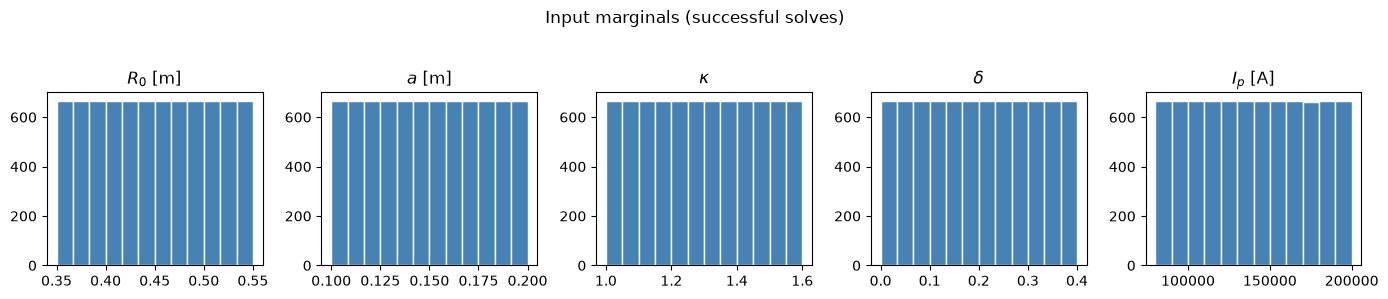

In [ ]:
# Input coverage — did LHS fill the box?
fig, axes = plt.subplots(1, 5, figsize=(14, 2.8))
for ax, j, name in zip(axes, range(5), PARAM_ORDER):
    ax.hist(bundle.inputs[:, j], bins=12, color="steelblue", edgecolor="white")
    ax.set_title(PARAM_LABELS[name])
fig.suptitle("Input marginals (successful solves)", y=1.05)
fig.tight_layout()
plt.show()

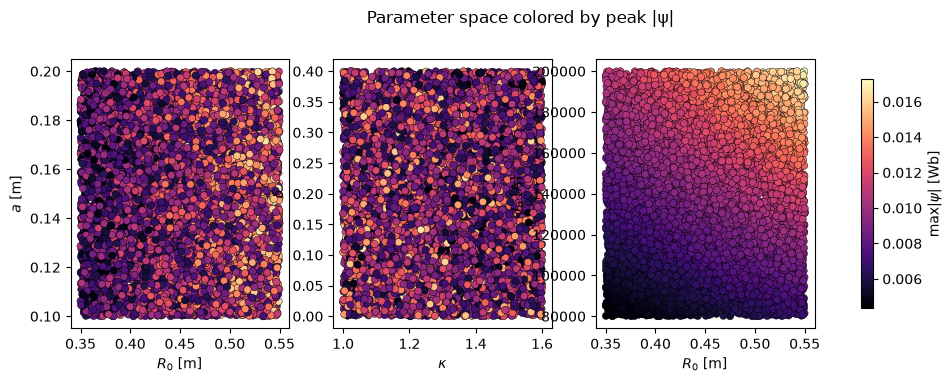

In [ ]:
# Pairwise scatter of a few shaping params, colored by |ψ|_max
psi_peak = np.nanmax(np.abs(bundle.psi), axis=(1, 2))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
pairs = [(0, 1), (2, 3), (0, 4)]  # (r0,a), (kappa,delta), (r0,Ip)
for ax, (i, j) in zip(axes, pairs):
    sc = ax.scatter(
        bundle.inputs[:, i], bundle.inputs[:, j],
        c=psi_peak, cmap="magma", s=28, edgecolors="k", linewidths=0.3,
    )
    ax.set_xlabel(PARAM_LABELS[PARAM_ORDER[i]])
    ax.set_ylabel(PARAM_LABELS[PARAM_ORDER[j]])
fig.colorbar(sc, ax=axes.ravel().tolist(), label=r"$\max|\psi|$ [Wb]", shrink=0.85)
fig.suptitle("Parameter space colored by peak |ψ|", y=1.02)
plt.show()

/var/folders/4t/b8mb58417k96y50ykz9_qzlr0000gn/T/ipykernel_76575/3879182280.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


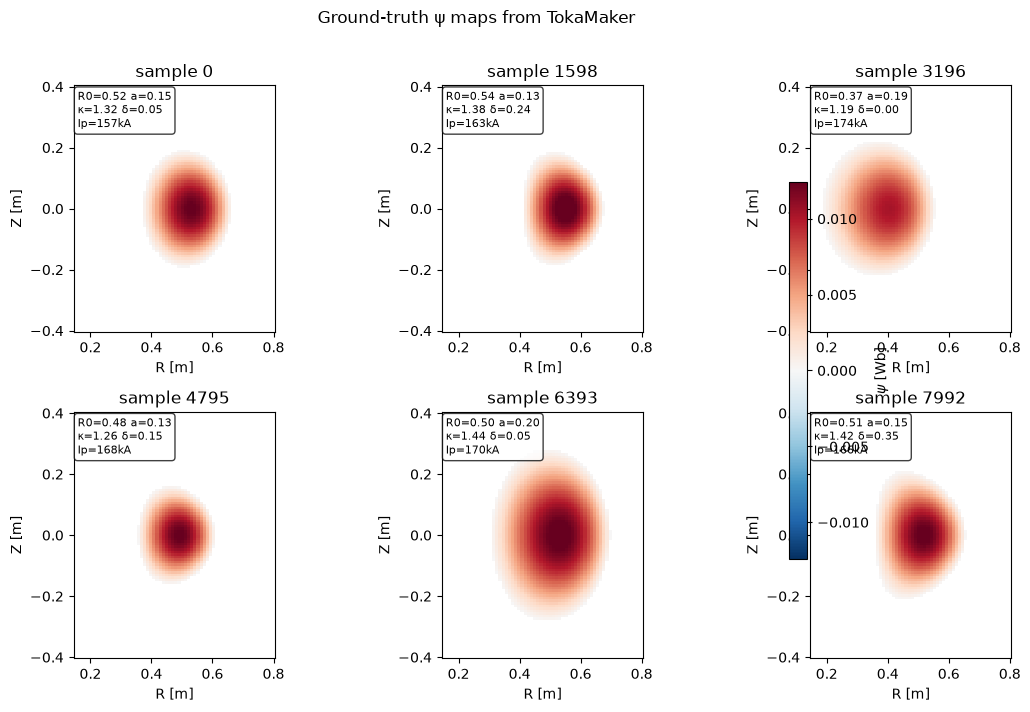

In [ ]:
def plot_psi(ax, R, Z, psi, title="", cmap="RdBu_r", vmin=None, vmax=None):
    mesh = ax.pcolormesh(R, Z, psi, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_aspect("equal")
    ax.set_xlabel("R [m]")
    ax.set_ylabel("Z [m]")
    ax.set_title(title)
    return mesh

# Gallery of a few true ψ maps
idxs = np.linspace(0, bundle.n_samples - 1, num=min(6, bundle.n_samples), dtype=int)
vmax = np.nanpercentile(np.abs(bundle.psi[idxs]), 98)
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, i in zip(axes.ravel(), idxs):
    m = plot_psi(ax, bundle.R, bundle.Z, bundle.psi[i], title=f"sample {i}", vmin=-vmax, vmax=vmax)
    # annotate inputs briefly
    r0, a, k, d, Ip = bundle.inputs[i]
    ax.text(
        0.02, 0.98,
        f"R0={r0:.2f} a={a:.2f}\nκ={k:.2f} δ={d:.2f}\nIp={Ip/1e3:.0f}kA",
        transform=ax.transAxes, va="top", fontsize=8,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.75),
    )
fig.colorbar(m, ax=axes.ravel().tolist(), shrink=0.7, label=r"$\psi$ [Wb]")
fig.suptitle("Ground-truth ψ maps from TokaMaker", y=1.01)
fig.tight_layout()
plt.show()

## 4. Train / val / test split + PCA rank

Same split the agent uses: held-out test + k-fold on the rest.

The cumulative-variance curve below answers: **how many PCA components do we need?**  
Pick `n_pca` near the knee where explained variance crosses ~95–99%. Too few → reconstruction error floor; too many → harder regression / overfit with small `N`.

In [ ]:
from autotokamak.surrogate.dataset import kfold
from autotokamak.surrogate.reduce import fit_pca, transform, inverse_transform
from autotokamak.surrogate.metrics import (
    baseline_mean_predictor_rmse,
    format_metric_report,
    psi_rmse,
    relative_l2,
    pixelwise_max_err,
    summarize_psi_errors,
)

# Need enough samples: n >= k + n_test. With N≈40: k=4, test_frac≈0.15 → ok.
splits = kfold(bundle, k=4, test_frac=0.15, seed=0)
print(f"test size: {splits.test_idx.size}")
for fold_i, (tr, va) in enumerate(splits.folds):
    print(f"  fold {fold_i}: train={tr.size}, val={va.size}")

# PCA variance curve on fold-0 train
tr0, va0 = splits.folds[0]
max_comp = min(20, tr0.size - 1, int(np.prod(bundle.grid_shape)))
pca_probe = fit_pca(bundle.psi[tr0], n_components=max_comp)
cum = np.cumsum(pca_probe.explained_variance_ratio)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(np.arange(1, len(cum) + 1), cum, marker="o", ms=4)
ax.axhline(0.95, color="gray", ls="--", label="95%")
ax.axhline(0.99, color="gray", ls=":", label="99%")
ax.set_xlabel("PCA components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("ψ is low-rank — choose n_components from this curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"components to ≥95%: {int(np.searchsorted(cum, 0.95) + 1)}")
print(f"components to ≥99%: {int(np.searchsorted(cum, 0.99) + 1)}")

## 5. Manual surrogate training

Pipeline per fold:

1. Fit PCA on train $\psi$ → `Y_train` shape `(n_train, n_pca)`  
2. Fit a model from `surrogate.zoo`: `X_train (n_train, 5)` → PCA coeffs  
3. Predict coeffs on val → inverse-transform → $\psi$ `(n_val, 96, 64)`  
4. Score in physical $\psi$ units (several metrics — see cheat sheet)

Compare against the **mean predictor baseline** (predict val as the train pixel-wise mean).  
If you cannot beat baseline (RMSE/baseline ≥ 1), the model is useless — same gate the agent scorer uses.

### How to read the metrics

This is **regression**, not classification, so there is no native “accuracy %.” We use close cousins:

| Metric | Good when… | Plain English |
|---|---|---|
| **RMSE / baseline** | **< 1** (e.g. 0.28) | Beat predicting the average map. **Primary score.** |
| **Error reduction %** | high (e.g. 72%) | `100 × (1 − RMSE/baseline)` |
| **R²** | near **1** | Familiar ML score; 1=perfect, 0≈mean of truth |
| **Correlation** | near **1** | Do hot/cold spots line up? |
| **Within 5% of truth** | high % | Accuracy-like: fraction of cells within 5% of true ψ |
| **Relative L2** | near **0** | Overall field error as a fraction of ‖ψ‖ |
| **MAE / RMSE** | smaller | Average / RMS absolute error in ψ units |

In [ ]:
from autotokamak.surrogate.zoo import make_model

N_PCA = min(12, tr0.size - 1)  # raise toward 16–20 once N is larger

candidates = {
    "poly_ridge": dict(alpha=1.0, degree=2),
    "kernel_ridge": dict(alpha=1e-2, gamma=1.0, kernel="rbf"),
    "mlp": dict(n_layers=1, layer_width=64, alpha=1e-4, learning_rate_init=1e-3),
    # "gp": dict(length_scale=1.0, noise_level=1e-3, alpha=1e-6),  # slow; enable if curious
}


def evaluate_model(name: str, hp: dict, train_idx, val_idx, n_pca: int):
    pca = fit_pca(bundle.psi[train_idx], n_components=n_pca)
    y_tr = transform(pca, bundle.psi[train_idx])
    est = make_model(name, **hp)
    est.fit(bundle.inputs[train_idx], y_tr)
    psi_hat = inverse_transform(pca, est.predict(bundle.inputs[val_idx]))
    baseline = baseline_mean_predictor_rmse(bundle.psi[train_idx], bundle.psi[val_idx])
    summary = summarize_psi_errors(
        bundle.psi[val_idx], psi_hat, baseline_rmse=baseline
    )
    return {
        "name": name,
        "hp": hp,
        "pca": pca,
        "est": est,
        "psi_hat": psi_hat,
        "rmse": summary["rmse"],
        "rel_l2": summary["rel_l2"],
        "max_err": summary["max_err"],
        "baseline": baseline,
        "summary": summary,
    }


rows = []
print(f"{'model':14s}  {'RMSE':>10s}  {'R²':>7s}  {'corr':>7s}  {'≤5%':>7s}  {'vs base':>8s}  {'err↓%':>7s}")
print("-" * 72)
for name, hp in candidates.items():
    fold_summaries = []
    for tr, va in splits.folds:
        out = evaluate_model(name, hp, tr, va, N_PCA)
        fold_summaries.append(out["summary"])
    mean = {k: float(np.nanmean([s[k] for s in fold_summaries])) for k in fold_summaries[0]}
    rows.append({"model": name, "hp": hp, **mean, "cv_rmse": mean["rmse"], "ratio": mean["rmse_vs_baseline"]})
    print(
        f"{name:14s}  {mean['rmse']:10.4g}  {mean['r2']:7.4f}  {mean['corr']:7.4f}  "
        f"{mean['pct_within_5pct']:6.1f}%  {mean['rmse_vs_baseline']:8.3f}  "
        f"{mean['pct_better_than_baseline']:6.1f}%"
    )

best = min(rows, key=lambda r: r["cv_rmse"])
print("\nBest CV model:", best["model"], best["hp"])
print("(≤5% = accuracy-like % of ψ cells within 5% of truth; vs base <1 beats mean predictor)")

### Visualize true vs predicted vs residual on a held-out fold

In [ ]:
# Refit best model on fold 0 for plots + full metric report
best_name, best_hp = best["model"], best["hp"]
viz = evaluate_model(best_name, best_hp, tr0, va0, N_PCA)
print(format_metric_report(viz["summary"], title=f"{best_name} — fold-0 validation"))

n_show = min(3, va0.size)
fig, axes = plt.subplots(n_show, 3, figsize=(10, 3.2 * n_show))
if n_show == 1:
    axes = np.asarray([axes])

for row, (sample_i, local_j) in enumerate(zip(va0[:n_show], range(n_show))):
    truth = bundle.psi[sample_i]
    pred = viz["psi_hat"][local_j]
    # mask pred outside where truth is NaN for fair residual view
    pred_masked = np.where(np.isfinite(truth), pred, np.nan)
    resid = truth - pred_masked
    v = np.nanpercentile(np.abs(truth), 98)
    rv = np.nanpercentile(np.abs(resid), 98) or 1e-6
    plot_psi(axes[row, 0], bundle.R, bundle.Z, truth, title=f"true [{sample_i}]", vmin=-v, vmax=v)
    plot_psi(axes[row, 1], bundle.R, bundle.Z, pred_masked, title="pred", vmin=-v, vmax=v)
    m = plot_psi(axes[row, 2], bundle.R, bundle.Z, resid, title="true−pred", cmap="coolwarm", vmin=-rv, vmax=rv)

fig.colorbar(m, ax=axes.ravel().tolist(), shrink=0.6, label="Wb")
fig.suptitle(f"{best_name} on fold-0 validation", y=1.01)
fig.tight_layout()
plt.show()

## 6. Held-out test score + save a winner

Train on **all non-test** samples, evaluate once on the test set (don't peek while tuning).
The printed report uses the same easy-to-read metrics as §5.

In [ ]:
import pickle

non_test = np.setdiff1d(np.arange(bundle.n_samples), splits.test_idx)
test_idx = splits.test_idx

pca = fit_pca(bundle.psi[non_test], n_components=N_PCA)
y_tr = transform(pca, bundle.psi[non_test])
winner = make_model(best_name, **best_hp)
winner.fit(bundle.inputs[non_test], y_tr)

psi_test_hat = inverse_transform(pca, winner.predict(bundle.inputs[test_idx]))
test_baseline = baseline_mean_predictor_rmse(bundle.psi[non_test], bundle.psi[test_idx])
test_summary = summarize_psi_errors(
    bundle.psi[test_idx], psi_test_hat, baseline_rmse=test_baseline
)
print(format_metric_report(test_summary, title=f"{best_name} — held-out TEST"))

payload = {
    "estimator": winner,
    "pca": pca,
    "model_name": best_name,
    "hyperparams": best_hp,
    "n_pca_components": N_PCA,
    "fit_indices": non_test,
    "test_indices": test_idx,
    "test_rmse": test_summary["rmse"],
    "test_baseline_rmse": test_baseline,
    "test_metrics": test_summary,
}
winner_path = RUN_DIR / "winner_manual.pkl"
with open(winner_path, "wb") as f:
    pickle.dump(payload, f)
print(f"Saved {winner_path}")

## 7. Optional: light Optuna search (same stack the agent uses)

Uncomment / run when you want a more serious hunt without the LLM loop.
Keep the time budget small at first.

In [ ]:
# Optional AutoML — set RUN_AUTOML = True to enable.
RUN_AUTOML = False

if RUN_AUTOML:
    from autotokamak.surrogate.optuna_search import (
        run_study,
        refit_winner,
        predict_with_winner,
        summarize_study,
    )
    from autotokamak.surrogate.schema import SearchSpec
    from autotokamak.surrogate.zoo import DEFAULT_SEARCH_SPACES

    automl_dir = RUN_DIR / "automl"
    automl_dir.mkdir(exist_ok=True)

    spec = SearchSpec.model_validate(
        {
            "round": 1,
            "n_pca_components": N_PCA,
            "val_metric": "psi_rmse",
            "action": "initial",
            "rationale": "manual notebook light search",
            "models": [
                {
                    "name": "poly_ridge",
                    "n_trials": 20,
                    "search_space": DEFAULT_SEARCH_SPACES["poly_ridge"],
                },
                {
                    "name": "kernel_ridge",
                    "n_trials": 20,
                    "search_space": DEFAULT_SEARCH_SPACES["kernel_ridge"],
                },
                {
                    "name": "mlp",
                    "n_trials": 15,
                    "search_space": DEFAULT_SEARCH_SPACES["mlp"],
                },
            ],
        }
    )
    # time budget is enforced inside run_study via Optuna; n_trials caps work per model
    study = run_study(spec, bundle=bundle, splits=splits, workdir=automl_dir)
    print(summarize_study(study))
    winner_path = automl_dir / "winner.pkl"
    refit_winner(study, bundle=bundle, splits=splits, save_to=winner_path)
    import joblib
    payload = joblib.load(winner_path)
    pred = predict_with_winner(payload, bundle.inputs[splits.test_idx])
    print("AutoML test RMSE:", psi_rmse(bundle.psi[splits.test_idx], pred))
else:
    print("Skipped AutoML (set RUN_AUTOML = True to run).")

Skipped AutoML (set RUN_AUTOML = True to run).


## Takeaways / what to try next

1. **Beat baseline first.** Ratio ≪ 1 on CV and test is the real win condition.
2. **Scale N.** 40 samples is for learning the pipeline; strong models usually want hundreds.
3. **PCA knobs.** If reconstruction error dominates, raise `N_PCA`; if overfit, lower it.
4. **Model bias.** `poly_ridge` is a strong, fast baseline on this low-rank physics. MLP needs more data / tuning.
5. **Agent failure modes to watch for.** Collapsing to the mean (ratio ≈ 1), wrong ψ convention, ignoring `success` / isoflux flags, or searching a broken hyperparameter box.

When you have a manual winner that clearly beats baseline, compare it to `examples/surrogate_meta/report.json` — that is the bar the agent currently fails to clear.